# Mix DIR → CQT (vivo / thinkpad / flow / thinkpad-2 / flow-2 / thinkpad-2 / flow-2)

Apply **device impulse responses** to cross-domain chord audio in memory, then extract CQT.

- Does **not** touch training audio/features (model stays clean-trained).
- **Always** convolves (p=1); **random DIR per sample** from the mic bank (`dir-prep.ipynb`).
- Process fully in memory — **no wet wavs on disk**; only CQT npz + CSV manifest.
- Same CQT params as clean / RIR pipelines.
- Inspect: **clean | dir | dir − clean** for all packs.


## Config

In [1]:
from os import path
import librosa
import pandas as pd
from IPython.display import display

# --- chord audio roots (non-training only) ---
CHORD_DATASETS = ["vivo", "thinkpad", "flow", "thinkpad-2", "flow-2"]
DATASET_ROOTS = {
    "vivo": path.normpath("../../datasets/vivo"),
    "thinkpad": path.normpath("../../datasets/thinkpad"),
    "flow": path.normpath("../../datasets/flow"),
    "thinkpad-2": path.normpath("../../datasets/thinkpad-2"),
    "flow-2": path.normpath("../../datasets/flow-2"),
}
FEATURES_DIR = path.normpath("../../features")
CLEAN_FEATURES = {
    "vivo": path.join(FEATURES_DIR, "vivo.npz"),
    "thinkpad": path.join(FEATURES_DIR, "thinkpad.npz"),
    "flow": path.join(FEATURES_DIR, "flow.npz"),
    "thinkpad-2": path.join(FEATURES_DIR, "thinkpad-2.npz"),
    "flow-2": path.join(FEATURES_DIR, "flow-2.npz"),
}

# --- DIR bank (from dir-prep.ipynb) ---
DIR_BANK = path.normpath("../../features/dir/dirs-mic6.npz")
BANK_TAG = "mic6"

# --- mix behaviour ---
RNG_SEED = 42
CONVOLVE_PROBABILITY = 1.0
assert CONVOLVE_PROBABILITY == 1.0, "This pipeline always convolves"

# --- outputs ---
OUT_NAME_TEMPLATE = "{dataset}-dir-{bank_tag}.npz"
MANIFEST_NAME_TEMPLATE = "{dataset}-dir-{bank_tag}.manifest.csv"
CKPT_NAME_TEMPLATE = "{dataset}-dir-{bank_tag}.ckpt.npz"
FORCE_REMIX = False
CHECKPOINT_EVERY = 50

DATASET_SEED_OFFSET = {"vivo": 101, "thinkpad": 202, "flow": 303, "thinkpad-2": 404, "flow-2": 505}

# --- CQT params (must match chord extraction) ---
AUDIO_MIN_DURATION = 2
AUDIO_SAMPLE_RATE = 48_000
CQT_HOP_LENGTH = 512
CQT_OCTAVES = 6
CQT_BINS_PER_OCTAVE = 36
CQT_FEATURE_FRAMES = round(AUDIO_MIN_DURATION * AUDIO_SAMPLE_RATE / CQT_HOP_LENGTH)
CQT_FMIN = librosa.note_to_hz("C1")

config_df = pd.DataFrame([
    {"key": "chord_datasets", "value": CHORD_DATASETS},
    {"key": "dir_bank", "value": DIR_BANK},
    {"key": "bank_tag", "value": BANK_TAG},
    {"key": "rng_seed", "value": RNG_SEED},
    {"key": "convolve_probability", "value": CONVOLVE_PROBABILITY},
    {"key": "force_remix", "value": FORCE_REMIX},
    {"key": "checkpoint_every", "value": CHECKPOINT_EVERY},
    {"key": "feature_bins", "value": CQT_BINS_PER_OCTAVE * CQT_OCTAVES},
    {"key": "feature_frames", "value": CQT_FEATURE_FRAMES},
    {"key": "out_template", "value": OUT_NAME_TEMPLATE},
]).set_index("key")
display(config_df)


,value
key,
chord_datasets,"[vivo, thinkpad, flow, thinkpad-2, flow-2]"
dir_bank,../../features/dir/dirs-mic6.npz
bank_tag,mic6
rng_seed,42
convolve_probability,1.0
force_remix,False
checkpoint_every,50
feature_bins,216
feature_frames,188


## Helpers

In [2]:
import csv
import re
from collections import OrderedDict
from os import makedirs, remove
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
from scipy.signal import fftconvolve
from IPython.display import display
from tqdm.notebook import tqdm
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

AUDIO_EXTS = {".wav", ".ogg", ".flac", ".mp3"}


def natural_key(s: str):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", s)]


def load_dir_bank(bank_path: str) -> dict:
    data = np.load(bank_path, allow_pickle=True)
    irs = data["irs"]
    names = data["names"].astype(str)
    devices = data["devices"].astype(str) if "devices" in data.files else data["rooms"].astype(str)
    target_sr = int(data["target_sr"]) if "target_sr" in data.files else AUDIO_SAMPLE_RATE
    assert target_sr == AUDIO_SAMPLE_RATE, f"DIR bank sr={target_sr} != {AUDIO_SAMPLE_RATE}"
    assert len(irs) > 0
    meta_df = pd.DataFrame([{
        "bank_path": bank_path,
        "n_dirs": len(names),
        "n_devices": int(len(np.unique(devices))),
        "target_sr": target_sr,
        "bank_tag": str(data["bank_tag"]) if "bank_tag" in data.files else "",
        "duration_s_median": float(np.median(data["durations_s"])) if "durations_s" in data.files else None,
    }])
    device_counts = (
        pd.Series(devices).value_counts().rename_axis("device").reset_index(name="n")
    )
    display(meta_df)
    display(device_counts)
    return {
        "irs": irs,
        "names": names,
        "devices": devices,
        "n": len(names),
        "bank_tag": str(data["bank_tag"]) if "bank_tag" in data.files else BANK_TAG,
    }


def resolve_audio_list(dataset: str) -> pd.DataFrame:
    root = Path(DATASET_ROOTS[dataset])
    assert root.is_dir(), f"Missing dataset root: {root}"
    clean_path = CLEAN_FEATURES.get(dataset)

    if clean_path and path.isfile(clean_path):
        clean = np.load(clean_path, allow_pickle=True)
        labels = np.asarray(clean["labels"]).astype(str)
        if "files" in clean.files:
            rels = np.asarray(clean["files"]).astype(str)
            rows = []
            for rel, lab in zip(rels, labels):
                p = root / rel
                if not p.is_file():
                    alt = p.with_suffix(".ogg" if p.suffix.lower() == ".wav" else ".wav")
                    if alt.is_file():
                        p = alt
                        rel = str(Path(rel).with_suffix(p.suffix))
                if not p.is_file():
                    raise FileNotFoundError(f"{dataset}: missing audio {root / rel}")
                rows.append({"relpath": rel, "path": str(p), "label": lab})
            return pd.DataFrame(rows)

        class_order = list(OrderedDict.fromkeys(labels))
        rows = []
        for cls in class_order:
            folder = root / cls
            assert folder.is_dir(), f"Missing class folder: {folder}"
            paths = sorted(
                [p for p in folder.iterdir() if p.suffix.lower() in AUDIO_EXTS],
                key=lambda p: natural_key(p.name),
            )
            n_expect = int((labels == cls).sum())
            if len(paths) != n_expect:
                raise ValueError(f"{dataset}/{cls}: found {len(paths)} audio, expected {n_expect}")
            for p in paths:
                rows.append({
                    "relpath": str(p.relative_to(root)),
                    "path": str(p),
                    "label": cls,
                })
        df = pd.DataFrame(rows)
        assert len(df) == len(labels)
        assert list(df["label"]) == list(labels)
        return df

    paths = sorted(
        [p for p in root.rglob("*") if p.suffix.lower() in AUDIO_EXTS],
        key=lambda p: (p.parent.name, natural_key(p.name)),
    )
    return pd.DataFrame([
        {"relpath": str(p.relative_to(root)), "path": str(p), "label": p.parent.name}
        for p in paths
    ])


def preprocess_cqt(cqt: np.ndarray) -> np.ndarray:
    if cqt.shape[1] < CQT_FEATURE_FRAMES:
        pad_width = CQT_FEATURE_FRAMES - cqt.shape[1]
        cqt = np.pad(cqt, pad_width=((0, 0), (0, pad_width)), mode="constant")
    else:
        cqt = cqt[:, :CQT_FEATURE_FRAMES]
    return cqt


def convolve_crop(y: np.ndarray, h: np.ndarray) -> np.ndarray:
    wet = fftconvolve(y, h, mode="full")
    wet = wet[: len(y)]
    peak = float(np.max(np.abs(wet)))
    if peak > 0:
        wet = wet / peak
    return wet.astype(np.float32)


def extract_cqt_from_audio(y: np.ndarray, sr: int) -> np.ndarray:
    cqt = librosa.cqt(
        y=y,
        sr=sr,
        fmin=CQT_FMIN,
        n_bins=CQT_BINS_PER_OCTAVE * CQT_OCTAVES,
        bins_per_octave=CQT_BINS_PER_OCTAVE,
        hop_length=CQT_HOP_LENGTH,
        window="hann",
    )
    cqt = np.abs(cqt)
    cqt = librosa.amplitude_to_db(cqt, ref=np.max)
    return preprocess_cqt(cqt).astype(np.float32)


def process_one(audio_path: str, h: np.ndarray) -> np.ndarray:
    y, sr = librosa.load(audio_path, sr=AUDIO_SAMPLE_RATE, mono=True)
    y = y.astype(np.float32)
    wet = convolve_crop(y, h)
    return extract_cqt_from_audio(wet, sr)


def save_dataset_checkpoint(ckpt_path, features, labels, files, manifest_rows, next_index, errors):
    np.savez_compressed(
        ckpt_path,
        features=np.asarray(features, dtype=np.float32),
        labels=np.asarray(labels),
        files=np.asarray(files),
        manifest_json=np.asarray(manifest_rows, dtype=object),
        next_index=np.asarray(int(next_index)),
        n_features=np.asarray(len(features)),
        errors_json=np.asarray(errors, dtype=object),
    )


def process_dataset(dataset: str, dir_bank: dict, rng: np.random.Generator) -> dict:
    inventory = resolve_audio_list(dataset)
    n = len(inventory)
    out_path = path.join(FEATURES_DIR, OUT_NAME_TEMPLATE.format(dataset=dataset, bank_tag=BANK_TAG))
    manifest_path = path.join(FEATURES_DIR, MANIFEST_NAME_TEMPLATE.format(dataset=dataset, bank_tag=BANK_TAG))
    ckpt_path = path.join(FEATURES_DIR, CKPT_NAME_TEMPLATE.format(dataset=dataset, bank_tag=BANK_TAG))

    if path.isfile(out_path) and not FORCE_REMIX:
        data = np.load(out_path, allow_pickle=True)
        return {
            "dataset": dataset,
            "status": "skipped_exists",
            "n_in": n,
            "n_out": int(data["features"].shape[0]),
            "shape": data["features"].shape,
            "out_path": out_path,
            "manifest_path": manifest_path if path.isfile(manifest_path) else None,
        }

    features, labels, files, manifest_rows, errors = [], [], [], [], []
    start_i = 0

    if path.isfile(ckpt_path) and not FORCE_REMIX:
        ckpt = np.load(ckpt_path, allow_pickle=True)
        features = list(ckpt["features"])
        labels = list(ckpt["labels"].astype(str))
        files = list(ckpt["files"].astype(str))
        manifest_rows = list(ckpt["manifest_json"])
        if "errors_json" in ckpt.files:
            errors = list(ckpt["errors_json"])
        start_i = int(ckpt["next_index"]) if "next_index" in ckpt.files else len(features)
        display(pd.DataFrame([{
            "dataset": dataset,
            "status": "resumed_checkpoint",
            "next_index": start_i,
            "n_features": len(features),
            "ckpt": ckpt_path,
        }]))
    elif FORCE_REMIX and path.isfile(ckpt_path):
        remove(ckpt_path)

    if start_i > 0:
        _ = rng.integers(0, dir_bank["n"], size=start_i)

    for i in tqdm(range(start_i, n), desc=f"DIR-CQT {dataset}", initial=start_i, total=n):
        row = inventory.iloc[i]
        dir_i = int(rng.integers(0, dir_bank["n"]))
        h = dir_bank["irs"][dir_i]
        try:
            cqt = process_one(row["path"], h)
            features.append(cqt)
            labels.append(row["label"])
            files.append(row["relpath"])
            manifest_rows.append({
                "out_index": len(features) - 1,
                "chord_index": i,
                "chord_file": row["relpath"],
                "chord_label": row["label"],
                "convolved": 1,
                "dir_index": dir_i,
                "dir_file": dir_bank["names"][dir_i],
                "dir_device": dir_bank["devices"][dir_i],
            })
        except Exception as exc:
            errors.append({"index": i, "path": row["path"], "error": str(exc)})

        if (i + 1) % CHECKPOINT_EVERY == 0:
            save_dataset_checkpoint(
                ckpt_path, features, labels, files, manifest_rows,
                next_index=i + 1, errors=errors,
            )

    if not features:
        raise RuntimeError(f"{dataset}: no features extracted ({len(errors)} errors)")

    payload = {
        "features": np.asarray(features, dtype=np.float32),
        "labels": np.asarray(labels).astype(str),
        "files": np.asarray(files).astype(str),
        "source_dataset": np.asarray(dataset),
        "source_audio_root": np.asarray(DATASET_ROOTS[dataset]),
        "source_dir_bank": np.asarray(DIR_BANK),
        "dir_bank_tag": np.asarray(dir_bank["bank_tag"]),
        "rng_seed": np.asarray(RNG_SEED),
        "dataset_seed_offset": np.asarray(DATASET_SEED_OFFSET.get(dataset, -1)),
        "convolve_probability": np.asarray(CONVOLVE_PROBABILITY),
        "audio_sample_rate": np.asarray(AUDIO_SAMPLE_RATE),
        "cqt_hop_length": np.asarray(CQT_HOP_LENGTH),
        "cqt_bins": np.asarray(CQT_BINS_PER_OCTAVE * CQT_OCTAVES),
        "cqt_frames": np.asarray(CQT_FEATURE_FRAMES),
    }
    np.savez_compressed(out_path, **payload)

    with open(manifest_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(manifest_rows[0].keys()))
        writer.writeheader()
        writer.writerows(manifest_rows)

    if path.isfile(ckpt_path):
        remove(ckpt_path)
    if errors:
        display(pd.DataFrame(errors))

    return {
        "dataset": dataset,
        "status": "mixed",
        "n_in": n,
        "n_out": int(payload["features"].shape[0]),
        "n_errors": len(errors),
        "shape": payload["features"].shape,
        "out_path": out_path,
        "manifest_path": manifest_path,
    }


display(pd.DataFrame([{"helpers": "ready"}]))


,helpers
0,ready


## Run convolve + CQT


In [3]:
import pandas as pd
from IPython.display import display

assert path.isfile(DIR_BANK), f"Missing DIR bank: {DIR_BANK} (run dir-prep.ipynb)"
for name in CHORD_DATASETS:
    assert name != "training", "Do not apply DIR into training features"
    assert path.isdir(DATASET_ROOTS[name]), f"Missing audio root: {DATASET_ROOTS[name]}"

dir_bank = load_dir_bank(DIR_BANK)

inv_rows = []
for name in CHORD_DATASETS:
    inv = resolve_audio_list(name)
    inv_rows.append({
        "dataset": name,
        "n": len(inv),
        "n_labels": int(inv["label"].nunique()),
        "example": inv.iloc[0]["relpath"],
        "audio_root": DATASET_ROOTS[name],
    })
display(pd.DataFrame(inv_rows))

results = []
for name in CHORD_DATASETS:
    offset = DATASET_SEED_OFFSET.get(name, 100 + CHORD_DATASETS.index(name))
    ds_rng = np.random.default_rng(RNG_SEED + offset)
    info = process_dataset(name, dir_bank, ds_rng)
    results.append(info)
    display(pd.DataFrame([info]))

results_df = pd.DataFrame(results)
display(results_df)


,bank_path,n_dirs,n_devices,target_sr,bank_tag,duration_s_median
0,../../features/dir/dirs-mic6.npz,6,6,48000,mic6,0.500021


,device,n
0,AKGD12,1
1,Crystal,1
2,Lomo52A5M,1
3,MelodiumRM6,1
4,OktavaMD57,1
5,STC4035,1


,dataset,n,n_labels,example,audio_root
0,vivo,1440,36,A#_diminished_4/A#_diminished_4-1.wav,../../datasets/vivo
1,thinkpad,1440,36,A#_diminished_4/A#_diminished_4-1.wav,../../datasets/thinkpad
2,flow,1440,36,A#_diminished_4/A#_diminished_4-1.wav,../../datasets/flow
3,thinkpad-2,1440,36,A#_diminished_4/A#_diminished_4-1.wav,../../datasets/thinkpad-2
4,flow-2,1440,36,A#_diminished_4/A#_diminished_4-1.wav,../../datasets/flow-2


,dataset,status,n_in,n_out,shape,out_path,manifest_path
0,vivo,skipped_exists,1440,1440,"(1440, 216, 188)",../../features/vivo-dir-mic6.npz,../../features/vivo-dir-mic6.manifest.csv


,dataset,status,n_in,n_out,shape,out_path,manifest_path
0,thinkpad,skipped_exists,1440,1440,"(1440, 216, 188)",../../features/thinkpad-dir-mic6.npz,../../features/thinkpad-dir-mic6.manifest.csv


...

,dataset,status,n_in,n_out,n_errors,shape,out_path,manifest_path
0,flow,mixed,1440,1440,0,"(1440, 216, 188)",../../features/flow-dir-mic6.npz,../../features/flow-dir-mic6.manifest.csv


DIR-CQT thinkpad-2:   0%|          | 0/1440 [00:00<?, ?it/s]

,dataset,status,n_in,n_out,n_errors,shape,out_path,manifest_path
0,thinkpad-2,mixed,1440,1440,0,"(1440, 216, 188)",../../features/thinkpad-2-dir-mic6.npz,../../features/thinkpad-2-dir-mic6.manifest.csv


,dataset,status,n_in,n_out,shape,out_path,manifest_path
0,flow-2,skipped_exists,1440,1440,"(1440, 216, 188)",../../features/flow-2-dir-mic6.npz,../../features/flow-2-dir-mic6.manifest.csv


,dataset,status,n_in,n_out,shape,out_path,manifest_path,n_errors
0,vivo,skipped_exists,1440,1440,"(1440, 216, 188)",../../features/vivo-dir-mic6.npz,../../features/vivo-dir-mic6.manifest.csv,NaN
1,thinkpad,skipped_exists,1440,1440,"(1440, 216, 188)",../../features/thinkpad-dir-mic6.npz,../../features/thinkpad-dir-mic6.manifest.csv,NaN
2,flow,mixed,1440,1440,"(1440, 216, 188)",../../features/flow-dir-mic6.npz,../../features/flow-dir-mic6.manifest.csv,0.0
3,thinkpad-2,mixed,1440,1440,"(1440, 216, 188)",../../features/thinkpad-2-dir-mic6.npz,../../features/thinkpad-2-dir-mic6.manifest.csv,0.0
4,flow-2,skipped_exists,1440,1440,"(1440, 216, 188)",../../features/flow-2-dir-mic6.npz,../../features/flow-2-dir-mic6.manifest.csv,NaN


## Verify


In [4]:
import numpy as np
import pandas as pd
from IPython.display import display

rows = []
for name in CHORD_DATASETS:
    out_path = path.join(FEATURES_DIR, OUT_NAME_TEMPLATE.format(dataset=name, bank_tag=BANK_TAG))
    man_path = path.join(FEATURES_DIR, MANIFEST_NAME_TEMPLATE.format(dataset=name, bank_tag=BANK_TAG))
    data = np.load(out_path, allow_pickle=True)
    x = data["features"]
    y = data["labels"].astype(str)
    man = pd.read_csv(man_path) if path.isfile(man_path) else None
    clean_path = CLEAN_FEATURES[name]
    clean_n = None
    clean_shape = None
    if path.isfile(clean_path):
        clean = np.load(clean_path, allow_pickle=True)
        clean_n = int(clean["features"].shape[0])
        clean_shape = clean["features"].shape
    rows.append({
        "dataset": name,
        "n": int(x.shape[0]),
        "shape": x.shape,
        "dtype": str(x.dtype),
        "n_classes": int(len(np.unique(y))),
        "finite": bool(np.isfinite(x).all()),
        "clean_n": clean_n,
        "clean_shape": clean_shape,
        "n_match_clean": clean_n == int(x.shape[0]) if clean_n is not None else None,
        "manifest_rows": len(man) if man is not None else None,
        "n_unique_dirs": int(man["dir_file"].nunique()) if man is not None else None,
        "all_convolved": bool((man["convolved"] == 1).all()) if man is not None else None,
    })
display(pd.DataFrame(rows))


,dataset,n,shape,dtype,n_classes,finite,clean_n,clean_shape,n_match_clean,manifest_rows,n_unique_dirs,all_convolved
0,vivo,1440,"(1440, 216, 188)",float32,36,True,1440,"(1440, 216, 188)",True,1440,6,True
1,thinkpad,1440,"(1440, 216, 188)",float32,36,True,1440,"(1440, 216, 188)",True,1440,6,True
2,flow,1440,"(1440, 216, 188)",float32,36,True,1440,"(1440, 216, 188)",True,1440,6,True
3,thinkpad-2,1440,"(1440, 216, 188)",float32,36,True,1440,"(1440, 216, 188)",True,1440,6,True
4,flow-2,1440,"(1440, 216, 188)",float32,36,True,1440,"(1440, 216, 188)",True,1440,6,True


## Inspect clean vs DIR CQT

Side-by-side **clean | dir | dir − clean** for every pack in `CHORD_DATASETS`.


,dataset,n,mae_db_mean,mae_db_p50,mae_db_p90,cos_sim_mean,cos_sim_min
0,vivo,1440,6.116271,6.26333,9.178582,0.991801,0.972924


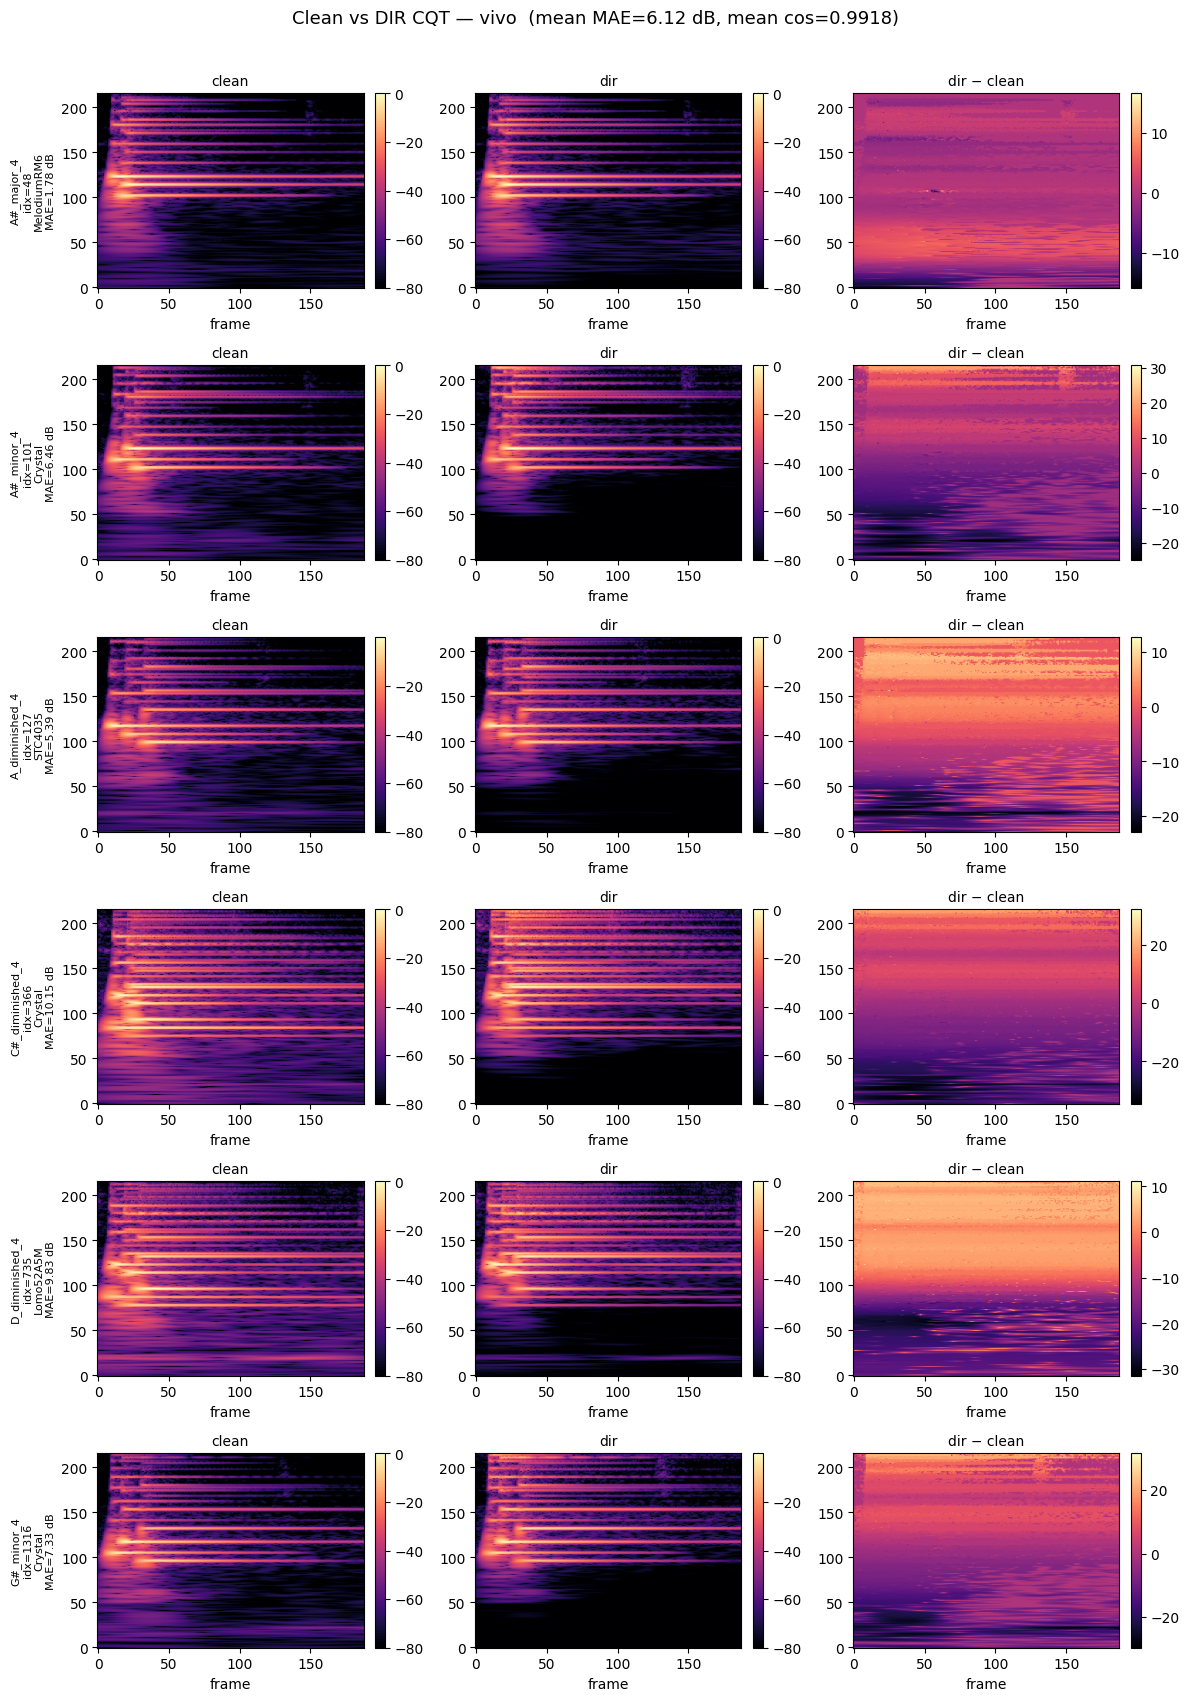

,dataset,out_index,chord_index,chord_label,chord_file,dir_device,dir_file,dir_index,convolved,mae_db,cos_sim
0,vivo,48,48,A#_major_4,A#_major_4/A#_major_4-17.wav,MelodiumRM6,IR_MelodiumRM6.wav,3,1,1.776829,0.999148
1,vivo,101,101,A#_minor_4,A#_minor_4/A#_minor_4-29.wav,Crystal,IR_Crystal.wav,1,1,6.464484,0.992877
2,vivo,127,127,A_diminished_4,A_diminished_4/A_diminished_4-16.wav,STC4035,IR_STC4035.wav,5,1,5.385221,0.994756
3,vivo,366,366,C#_diminished_4,C#_diminished_4/C#_diminished_4-15.wav,Crystal,IR_Crystal.wav,1,1,10.146595,0.982167
4,vivo,735,735,D_diminished_4,D_diminished_4/D_diminished_4-23.wav,Lomo52A5M,IR_Lomo52A5M.wav,2,1,9.826274,0.984804
5,vivo,1316,1316,G#_minor_4,G#_minor_4/G#_minor_4-6.wav,Crystal,IR_Crystal.wav,1,1,7.334926,0.990368


,dataset,n,mae_db_mean,mae_db_p50,mae_db_p90,cos_sim_mean,cos_sim_min
0,thinkpad,1440,8.53532,8.674196,12.105093,0.982169,0.955661


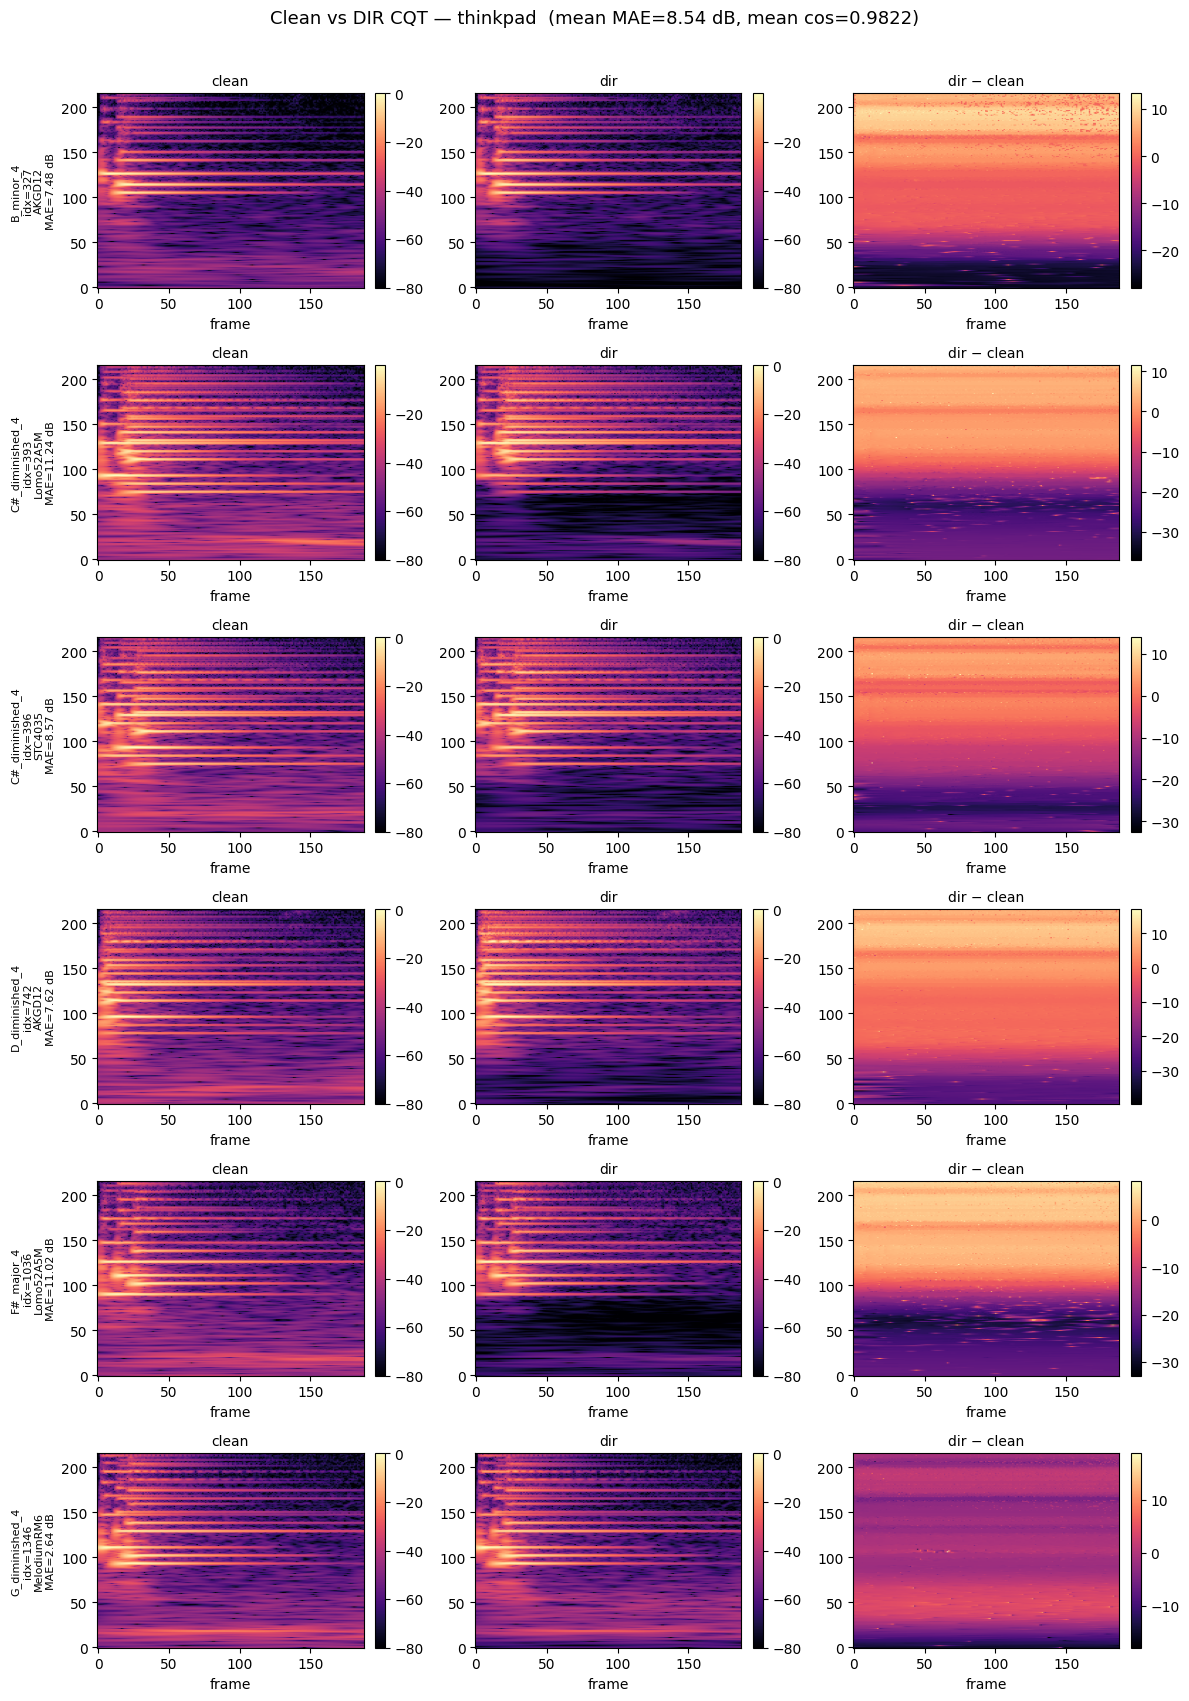

,dataset,out_index,chord_index,chord_label,chord_file,dir_device,dir_file,dir_index,convolved,mae_db,cos_sim
0,thinkpad,327,327,B_minor_4,B_minor_4/B_minor_4-16.wav,AKGD12,IR_AKGD12.wav,0,1,7.479337,0.985782
1,thinkpad,393,393,C#_diminished_4,C#_diminished_4/C#_diminished_4-4.wav,Lomo52A5M,IR_Lomo52A5M.wav,2,1,11.237917,0.976061
2,thinkpad,396,396,C#_diminished_4,C#_diminished_4/C#_diminished_4-6.wav,STC4035,IR_STC4035.wav,5,1,8.573248,0.983622
3,thinkpad,742,742,D_diminished_4,D_diminished_4/D_diminished_4-3.wav,AKGD12,IR_AKGD12.wav,0,1,7.619404,0.980452
4,thinkpad,1036,1036,F#_major_4,F#_major_4/F#_major_4-6.wav,Lomo52A5M,IR_Lomo52A5M.wav,2,1,11.018101,0.979432
5,thinkpad,1346,1346,G_diminished_4,G_diminished_4/G_diminished_4-33.wav,MelodiumRM6,IR_MelodiumRM6.wav,3,1,2.639542,0.997588


,dataset,n,mae_db_mean,mae_db_p50,mae_db_p90,cos_sim_mean,cos_sim_min
0,flow,1440,7.870954,7.9743,11.129768,0.985719,0.963993


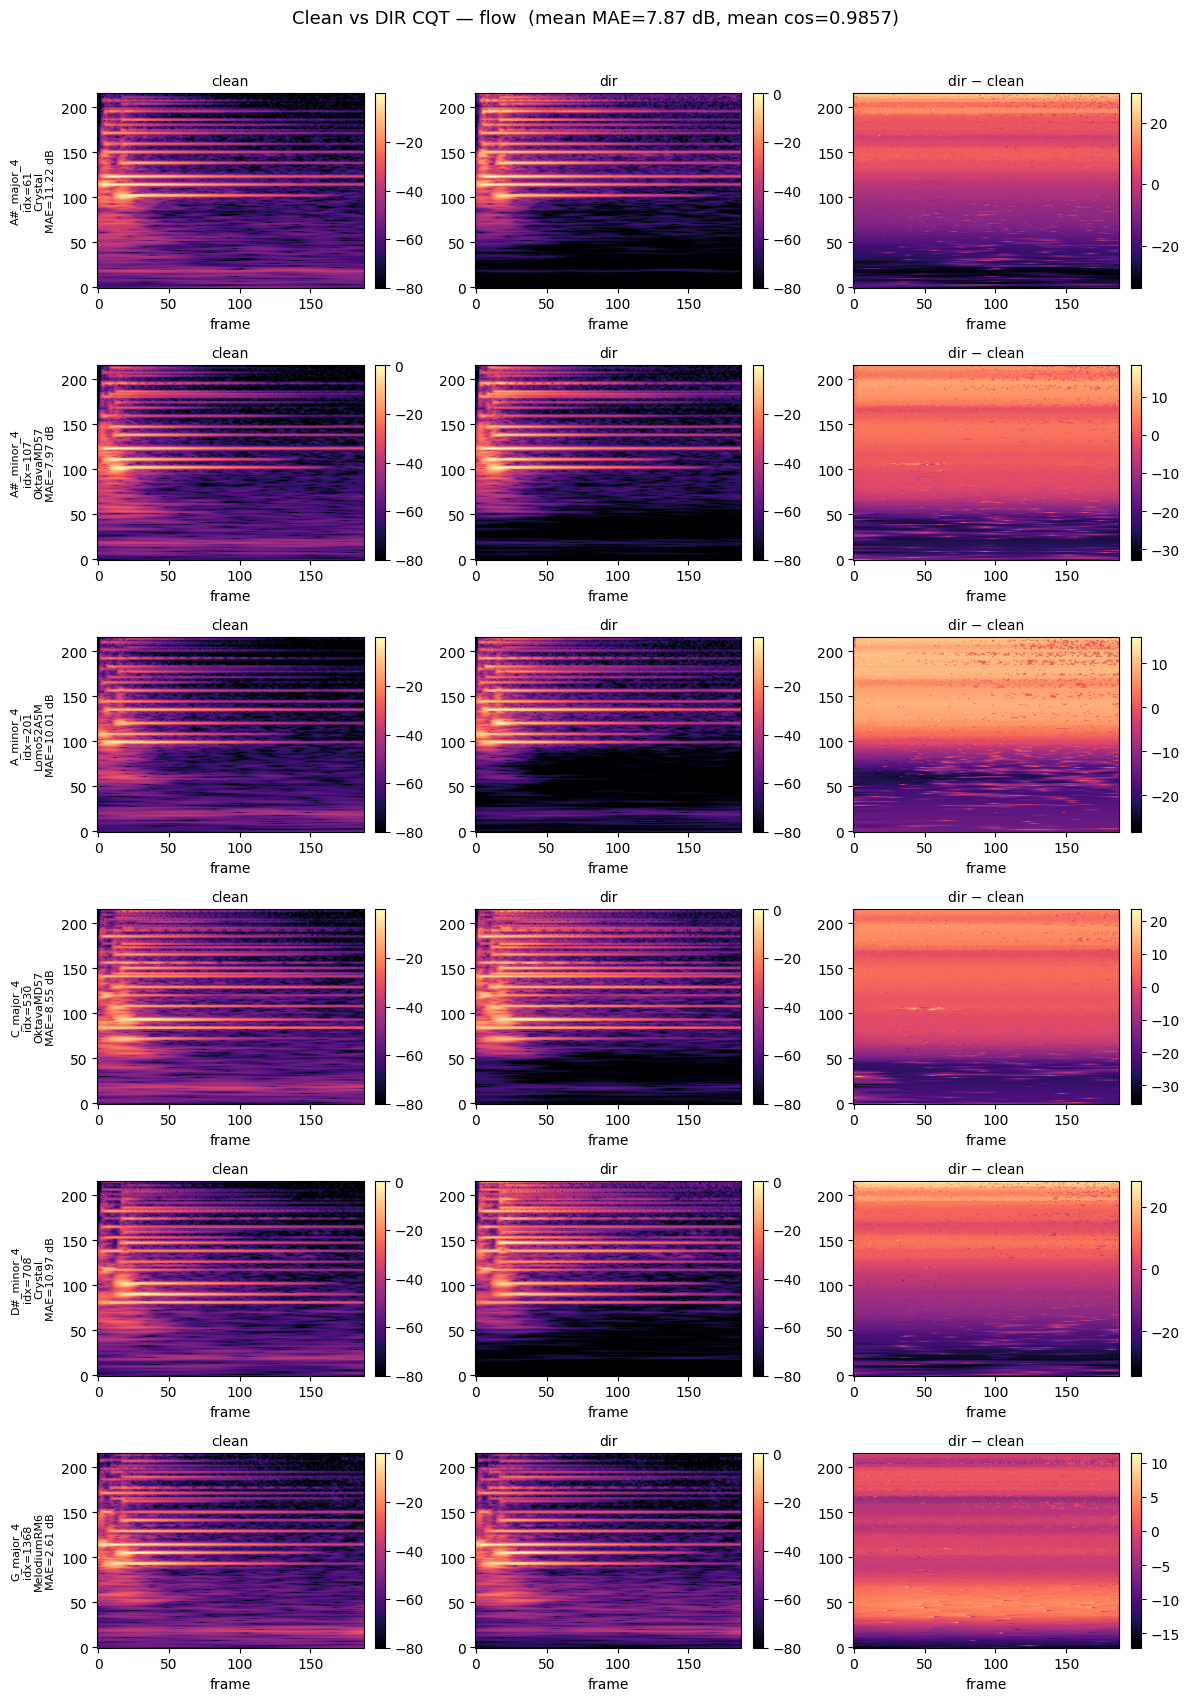

,dataset,out_index,chord_index,chord_label,chord_file,dir_device,dir_file,dir_index,convolved,mae_db,cos_sim
0,flow,61,61,A#_major_4,A#_major_4/A#_major_4-29.wav,Crystal,IR_Crystal.wav,1,1,11.223641,0.976967
1,flow,107,107,A#_minor_4,A#_minor_4/A#_minor_4-34.wav,OktavaMD57,IR_OktavaMD57.wav,4,1,7.972265,0.986095
2,flow,201,201,A_minor_4,A_minor_4/A_minor_4-10.wav,Lomo52A5M,IR_Lomo52A5M.wav,2,1,10.009895,0.985120
3,flow,530,530,C_major_4,C_major_4/C_major_4-19.wav,OktavaMD57,IR_OktavaMD57.wav,4,1,8.546604,0.981214
4,flow,708,708,D#_minor_4,D#_minor_4/D#_minor_4-35.wav,Crystal,IR_Crystal.wav,1,1,10.966197,0.976928
5,flow,1368,1368,G_major_4,G_major_4/G_major_4-17.wav,MelodiumRM6,IR_MelodiumRM6.wav,3,1,2.614470,0.997936


,dataset,n,mae_db_mean,mae_db_p50,mae_db_p90,cos_sim_mean,cos_sim_min
0,thinkpad-2,1440,8.686177,8.855763,12.448518,0.977674,0.941731


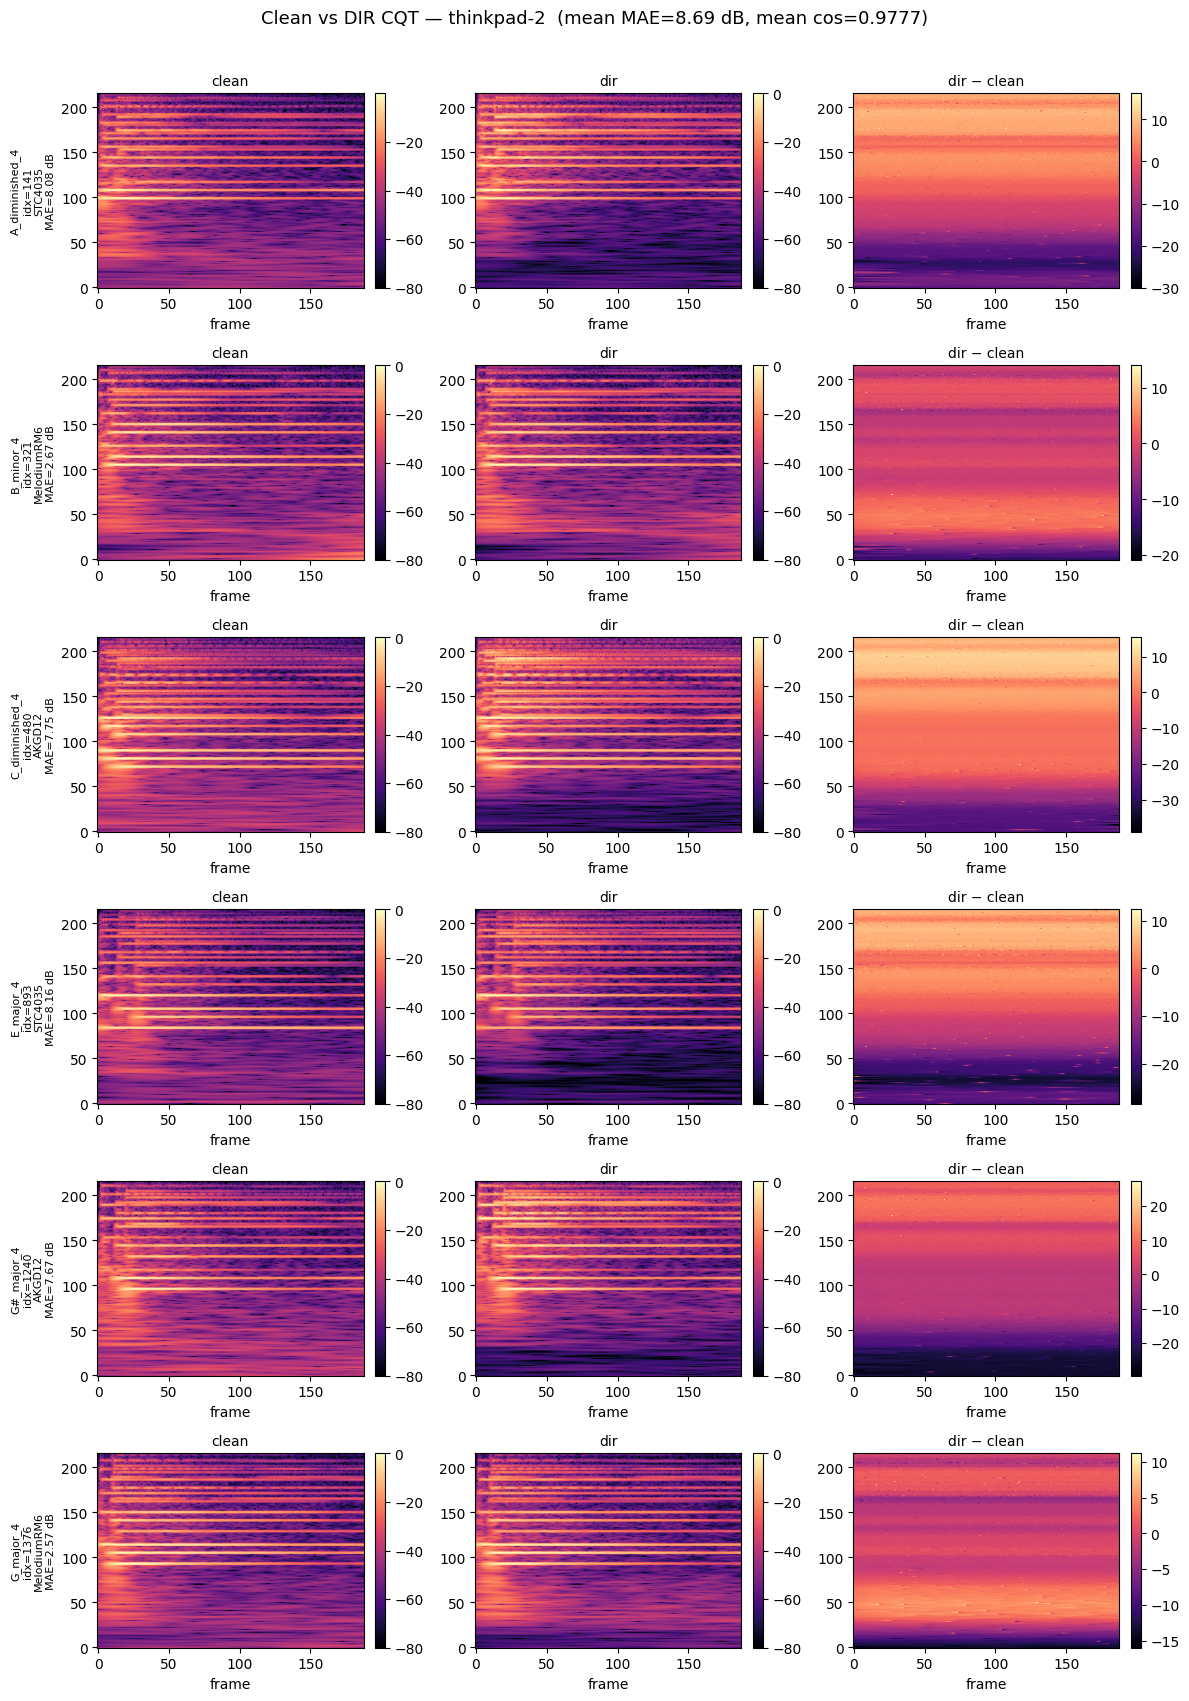

,dataset,out_index,chord_index,chord_label,chord_file,dir_device,dir_file,dir_index,convolved,mae_db,cos_sim
0,thinkpad-2,141,141,A_diminished_4,A_diminished_4/A_diminished_4-29.wav,STC4035,IR_STC4035.wav,5,1,8.082439,0.982565
1,thinkpad-2,321,321,B_minor_4,B_minor_4/B_minor_4-10.wav,MelodiumRM6,IR_MelodiumRM6.wav,3,1,2.669030,0.996835
2,thinkpad-2,480,480,C_diminished_4,C_diminished_4/C_diminished_4-1.wav,AKGD12,IR_AKGD12.wav,0,1,7.748450,0.975194
3,thinkpad-2,893,893,E_major_4,E_major_4/E_major_4-21.wav,STC4035,IR_STC4035.wav,5,1,8.163990,0.984633
4,thinkpad-2,1240,1240,G#_major_4,G#_major_4/G#_major_4-1.wav,AKGD12,IR_AKGD12.wav,0,1,7.670922,0.975345
5,thinkpad-2,1376,1376,G_major_4,G_major_4/G_major_4-24.wav,MelodiumRM6,IR_MelodiumRM6.wav,3,1,2.574329,0.996980


,dataset,n,mae_db_mean,mae_db_p50,mae_db_p90,cos_sim_mean,cos_sim_min
0,flow-2,1440,8.403101,8.636673,12.08568,0.980615,0.947346


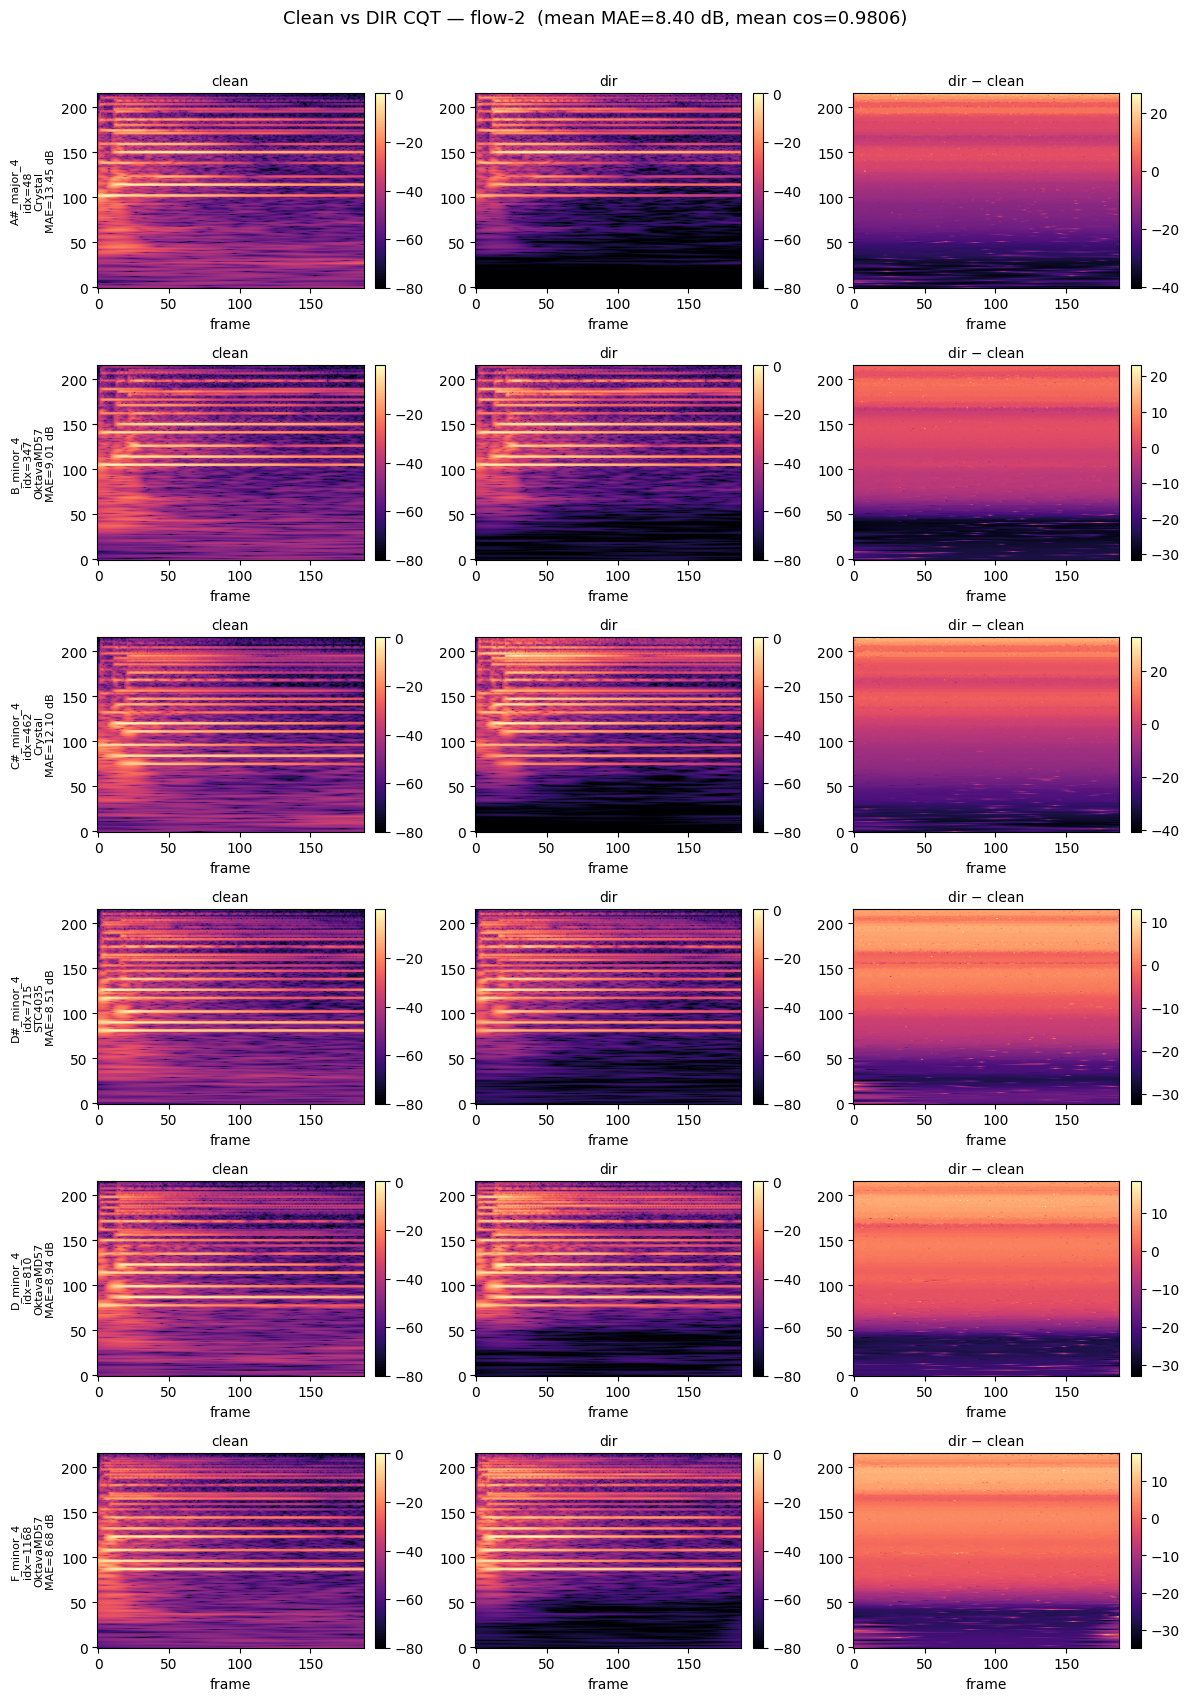

,dataset,out_index,chord_index,chord_label,chord_file,dir_device,dir_file,dir_index,convolved,mae_db,cos_sim
0,flow-2,48,48,A#_major_4,A#_major_4/A#_major_4-17.wav,Crystal,IR_Crystal.wav,1,1,13.452684,0.973556
1,flow-2,347,347,B_minor_4,B_minor_4/B_minor_4-34.wav,OktavaMD57,IR_OktavaMD57.wav,4,1,9.009643,0.978468
2,flow-2,462,462,C#_minor_4,C#_minor_4/C#_minor_4-3.wav,Crystal,IR_Crystal.wav,1,1,12.104282,0.965468
3,flow-2,715,715,D#_minor_4,D#_minor_4/D#_minor_4-5.wav,STC4035,IR_STC4035.wav,5,1,8.512194,0.985212
4,flow-2,810,810,D_minor_4,D_minor_4/D_minor_4-19.wav,OktavaMD57,IR_OktavaMD57.wav,4,1,8.939342,0.975451
5,flow-2,1168,1168,F_minor_4,F_minor_4/F_minor_4-17.wav,OktavaMD57,IR_OktavaMD57.wav,4,1,8.679692,0.977584


,dataset,out_index,chord_index,chord_label,chord_file,dir_device,dir_file,dir_index,convolved,mae_db,cos_sim
0,vivo,48,48,A#_major_4,A#_major_4/A#_major_4-17.wav,MelodiumRM6,IR_MelodiumRM6.wav,3,1,1.776829,0.999148
1,vivo,101,101,A#_minor_4,A#_minor_4/A#_minor_4-29.wav,Crystal,IR_Crystal.wav,1,1,6.464484,0.992877
2,vivo,127,127,A_diminished_4,A_diminished_4/A_diminished_4-16.wav,STC4035,IR_STC4035.wav,5,1,5.385221,0.994756
3,vivo,366,366,C#_diminished_4,C#_diminished_4/C#_diminished_4-15.wav,Crystal,IR_Crystal.wav,1,1,10.146595,0.982167
4,vivo,735,735,D_diminished_4,D_diminished_4/D_diminished_4-23.wav,Lomo52A5M,IR_Lomo52A5M.wav,2,1,9.826274,0.984804
5,vivo,1316,1316,G#_minor_4,G#_minor_4/G#_minor_4-6.wav,Crystal,IR_Crystal.wav,1,1,7.334926,0.990368
6,thinkpad,327,327,B_minor_4,B_minor_4/B_minor_4-16.wav,AKGD12,IR_AKGD12.wav,0,1,7.479337,0.985782
7,thinkpad,393,393,C#_diminished_4,C#_diminished_4/C#_diminished_4-4.wav,Lomo52A5M,IR_Lomo52A5M.wav,2,1,11.237917,0.976061
8,thinkpad,396,396,C#_diminished_4,C#_diminished_4/C#_diminished_4-6.wav,STC4035,IR_STC4035.wav,5,1,8.573248,0.983622
9,thinkpad,742,742,D_diminished_4,D_diminished_4/D_diminished_4-3.wav,AKGD12,IR_AKGD12.wav,0,1,7.619404,0.980452


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

INSPECT_DATASETS = list(CHORD_DATASETS)
INSPECT_N = 6
INSPECT_SEED = 0
INSPECT_DIR_DEVICES = None  # e.g. ["AKGD12", "Crystal"]

all_sample_frames = []

for INSPECT_DATASET in INSPECT_DATASETS:
    clean_path = CLEAN_FEATURES[INSPECT_DATASET]
    dir_path = path.join(
        FEATURES_DIR,
        OUT_NAME_TEMPLATE.format(dataset=INSPECT_DATASET, bank_tag=BANK_TAG),
    )
    man_path = path.join(
        FEATURES_DIR,
        MANIFEST_NAME_TEMPLATE.format(dataset=INSPECT_DATASET, bank_tag=BANK_TAG),
    )
    if not path.isfile(clean_path) or not path.isfile(dir_path):
        display(pd.DataFrame([{"dataset": INSPECT_DATASET, "status": "skip_missing"}]))
        continue

    clean = np.load(clean_path, allow_pickle=True)
    dirt = np.load(dir_path, allow_pickle=True)
    man = pd.read_csv(man_path)
    clean_x = clean["features"]
    dir_x = dirt["features"]
    man = man.sort_values("out_index").reset_index(drop=True)
    n = min(len(clean_x), len(dir_x), len(man))

    pool = man.index.to_numpy()[:n]
    if INSPECT_DIR_DEVICES is not None:
        allow = set(INSPECT_DIR_DEVICES)
        pool = man.index[man["dir_device"].isin(allow) & (man.index < n)].to_numpy()
        if len(pool) == 0:
            raise ValueError(f"{INSPECT_DATASET}: no rows for devices={INSPECT_DIR_DEVICES}")

    rng = np.random.default_rng(INSPECT_SEED + hash(INSPECT_DATASET) % 10_000)
    n_show = min(INSPECT_N, len(pool))
    out_idx = np.sort(rng.choice(pool, size=n_show, replace=False))

    mae_all = np.mean(
        np.abs(dir_x[:n].astype(np.float32) - clean_x[:n].astype(np.float32)),
        axis=(1, 2),
    )
    cos_all = []
    for j in range(n):
        a = clean_x[j].ravel().astype(np.float64)
        b = dir_x[j].ravel().astype(np.float64)
        cos_all.append(float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)))
    cos_all = np.asarray(cos_all)

    display(pd.DataFrame([{
        "dataset": INSPECT_DATASET,
        "n": n,
        "mae_db_mean": float(mae_all.mean()),
        "mae_db_p50": float(np.median(mae_all)),
        "mae_db_p90": float(np.percentile(mae_all, 90)),
        "cos_sim_mean": float(cos_all.mean()),
        "cos_sim_min": float(cos_all.min()),
    }]))

    fig, axes = plt.subplots(n_show, 3, figsize=(12, 2.8 * n_show), squeeze=False)
    for r, i in enumerate(out_idx):
        c = clean_x[i]
        m = dir_x[i]
        d = m.astype(np.float32) - c.astype(np.float32)
        for ax, img, title in zip(axes[r], [c, m, d], ["clean", "dir", "dir − clean"]):
            im = ax.imshow(img, origin="lower", aspect="auto", cmap="magma")
            ax.set_title(title, fontsize=10)
            ax.set_xlabel("frame")
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        lab = str(man.loc[i, "chord_label"])
        dev = str(man.loc[i, "dir_device"])
        axes[r, 0].set_ylabel(f"{lab}\nidx={i}\n{dev}\nMAE={mae_all[i]:.2f} dB", fontsize=8)

    fig.suptitle(
        f"Clean vs DIR CQT — {INSPECT_DATASET}  "
        f"(mean MAE={mae_all.mean():.2f} dB, mean cos={cos_all.mean():.4f})",
        fontsize=13, y=1.01,
    )
    fig.tight_layout()
    plt.show()

    sample_df = man.loc[out_idx, [
        "out_index", "chord_index", "chord_label", "chord_file",
        "dir_device", "dir_file", "dir_index", "convolved",
    ]].copy()
    sample_df.insert(0, "dataset", INSPECT_DATASET)
    sample_df["mae_db"] = mae_all[out_idx]
    sample_df["cos_sim"] = cos_all[out_idx]
    sample_df = sample_df.reset_index(drop=True)
    display(sample_df)
    all_sample_frames.append(sample_df)

if all_sample_frames:
    display(pd.concat(all_sample_frames, ignore_index=True))
